In [31]:
# import bioframe as bf
import torch
from gpzoo.kernels import batched_RBF, batched_MGGP_RBF
from torch import distributions
import matplotlib.pyplot as plt
from torch import nn, optim
from tqdm.autonotebook import tqdm
from gpzoo.utilities import add_jitter, whitened_KL
from gpzoo.gp import WSVGP, MGGP_WSVGP
import cooler
from matplotlib.colors import LogNorm
import numpy as np
import cooltools
import pandas as pd
import os, subprocess

In [32]:
# Define the grid range and resolution
grid_size = 30  # Number of points per dimension
x1 = torch.linspace(-2, 2, grid_size)
x2 = torch.linspace(-2, 2, grid_size)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X = torch.stack([x1.flatten(), x2.flatten()], dim=1)

In [33]:
X

tensor([[-2.0000, -2.0000],
        [-2.0000, -1.8621],
        [-2.0000, -1.7241],
        ...,
        [ 2.0000,  1.7241],
        [ 2.0000,  1.8621],
        [ 2.0000,  2.0000]])

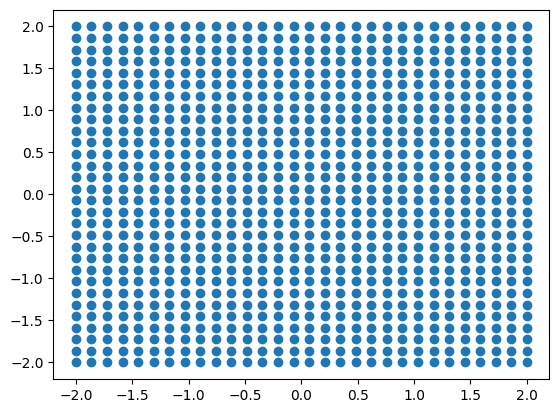

In [34]:
plt.scatter(X[:, 0], X[:, 1])

In [35]:
M = 800
jitter = 1e-5

kernel = batched_RBF(sigma=0.2, lengthscale=0.5)
gp = WSVGP(kernel, M=M, jitter=jitter)

idx = torch.multinomial(torch.ones(X.shape[0]), num_samples=M, replacement=False)

gp.Lu = nn.Parameter(1e-4*torch.eye(M).clone())
gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)
# mu = torch.squeeze(torch.stack((torch.torch.sin(torch.pi * gp.Z/10.0), torch.cos(torch.pi * gp.Z/10.0), torch.torch.sin(torch.pi * gp.Z/10.0))))
mu = gp.init_mean(X, X)
gp.mu = nn.Parameter(mu.T)

torch.Size([900, 800])
torch.Size([900, 2])


/tmp/ipykernel_766736/780824027.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp.Z = nn.Parameter(torch.tensor(X[idx]), requires_grad=False)


In [36]:
X.shape

torch.Size([900, 2])

In [37]:
# Define the grid range and resolution
grid_size = 30  # Number of points per dimension
x1 = torch.linspace(-2, 2, grid_size)
x2 = torch.linspace(-2, 2, grid_size)

# Create a meshgrid
x1, x2 = torch.meshgrid(x1, x2, indexing="ij")

# Stack to get a grid of shape (grid_size * grid_size, 2)
X_test = torch.stack([x1.flatten(), x2.flatten()], dim=1)

In [38]:
qF, qZ, pZ = gp(X_test, diag=False)

In [39]:
qF

MultivariateNormal(loc: torch.Size([2, 900]), scale_tril: torch.Size([2, 900, 900]))

In [54]:
N = 16
F_samples = qF.sample((N,)).detach()
F_mean = qF.mean.detach()

In [55]:
F_samples.shape

torch.Size([16, 2, 900])

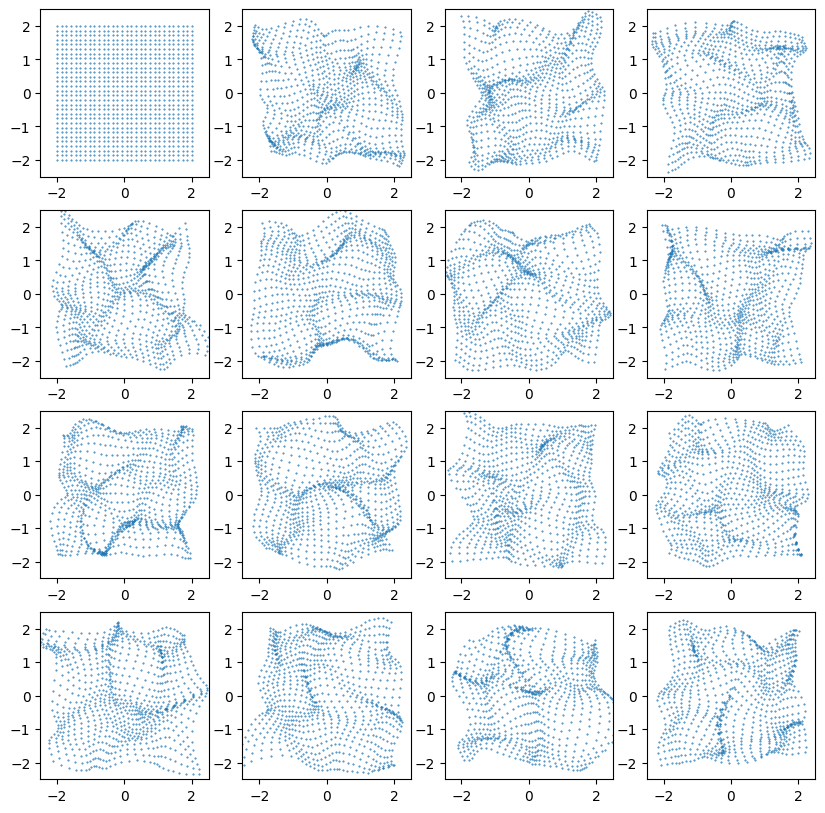

In [56]:
plt.figure(figsize=(10, 10))
for i in range(N):
    plt.subplot(4, 4, i+1)
    if i==0:
        plt.scatter(X[:, 0], X[:, 1], s=0.2)
    else:
        plt.scatter(F_samples[i, 0], F_samples[i, 1], s=0.2)

    plt.xlim([-2.5, 2.5])
    plt.ylim([-2.5, 2.5])

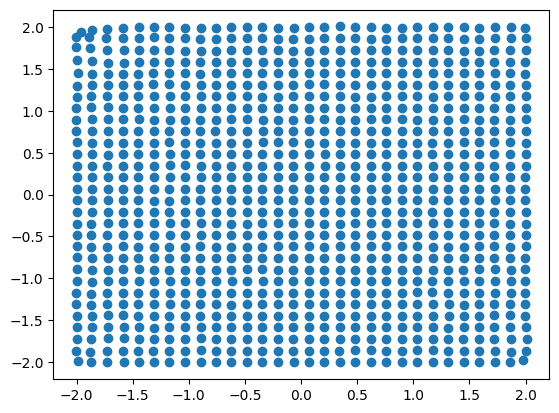

In [30]:
plt.scatter(F_mean[0], F_mean[1])

In [167]:
N = 500
X1D = torch.linspace(-2, 2, N)
kernel = batched_RBF(sigma=2.0, lengthscale=0.1)
M = 400
jitter=1e-4
gp1D = WSVGP(kernel, M=M, jitter=jitter)

gp1D.mu = nn.Parameter(torch.zeros(M))

idx = torch.multinomial(torch.ones(X1D.shape[0]), num_samples=M, replacement=False)
gp1D.Lu = nn.Parameter(1e-4*torch.eye(M).clone())
gp1D.Z = nn.Parameter(torch.tensor(X1D[idx]), requires_grad=False)

/tmp/ipykernel_3040487/4265795866.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gp1D.Z = nn.Parameter(torch.tensor(X1D[idx]), requires_grad=False)


In [168]:
gp1D.mu.shape

torch.Size([400])

In [169]:
N_test = 2000
X_test = torch.linspace(-2, 2, N_test)

In [170]:
N_samples = 25
qF, qU, pU = gp1D(X_test, diag=False, verbose=False)
F_samples = qF.sample((N_samples,)).squeeze()

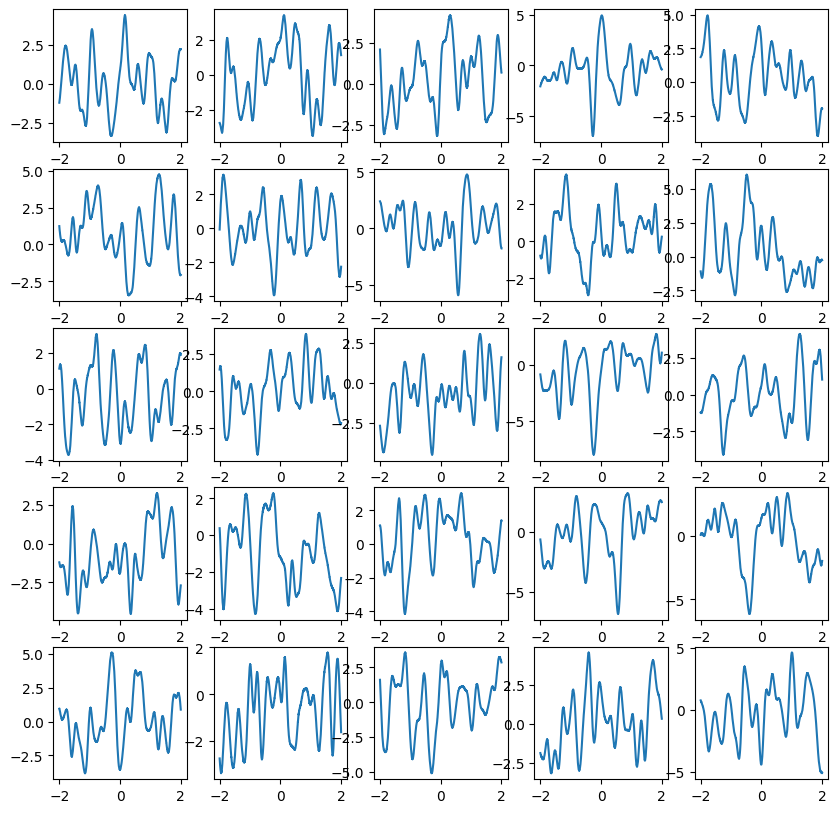

In [171]:
plt.figure(figsize=(10, 10))
for i in range(N_samples):
    plt.subplot(5, 5, i+1)
    plt.plot(X_test, F_samples[i])